# DAY 01 : Baseline model implementation

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import pandas as pd
df = pd.read_csv('heart.csv') 
X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.7951219512195122
Confusion Matrix:
 [[73 29]
 [13 90]]


# DAY 02 : Random forest implemention

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
df = pd.read_csv("heart.csv")
X = df.drop('target', axis=1)
y = df['target']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
rf_model = RandomForestClassifier(
    n_estimators=100,       
    max_depth=5,           
    random_state=42         
)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

In [7]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8731707317073171

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.80      0.86       102
           1       0.83      0.94      0.88       103

    accuracy                           0.87       205
   macro avg       0.88      0.87      0.87       205
weighted avg       0.88      0.87      0.87       205



# SVM implementation

In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
df = pd.read_csv('heart.csv') 
X = df.drop('target', axis=1)
y = df['target']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [9]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
svm_linear = SVC(kernel='linear', random_state=42)
svm_linear.fit(X_train, y_train)
y_pred_linear = svm_linear.predict(X_test)
svm_rbf = SVC(kernel='rbf', gamma='scale', random_state=42)
svm_rbf.fit(X_train, y_train)
y_pred_rbf = svm_rbf.predict(X_test)

In [10]:
print("Linear Kernel Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_linear))
print(classification_report(y_test, y_pred_linear))

print("\n RBF Kernel Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_rbf))
print(classification_report(y_test, y_pred_rbf))

Linear Kernel Performance:
Accuracy: 0.8146341463414634
              precision    recall  f1-score   support

           0       0.90      0.71      0.79       102
           1       0.76      0.92      0.83       103

    accuracy                           0.81       205
   macro avg       0.83      0.81      0.81       205
weighted avg       0.83      0.81      0.81       205


 RBF Kernel Performance:
Accuracy: 0.8878048780487805
              precision    recall  f1-score   support

           0       0.93      0.83      0.88       102
           1       0.85      0.94      0.89       103

    accuracy                           0.89       205
   macro avg       0.89      0.89      0.89       205
weighted avg       0.89      0.89      0.89       205



# Neural Network Implementation

In [222]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_prob = model.predict(X_val).flatten()
y_pred = (y_pred_prob > 0.5).astype("int32")

accuracy = accuracy_score(y_val, y_pred)
print("Accuracy score:", accuracy)

print("Classification Report:")
print(classification_report(y_val, y_pred))

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Accuracy score: 0.9817073170731707
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98        80
           1       0.98      0.99      0.98        84

    accuracy                           0.98       164
   macro avg       0.98      0.98      0.98       164
weighted avg       0.98      0.98      0.98       164



In [224]:
import os, json, joblib, numpy as np, pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks

DATA_PATH   = "heart.csv"    
TARGET_COL  = "target"       
SEED        = 42
OUT_DIR     = "nn_outputs"
os.makedirs(OUT_DIR, exist_ok=True)
np.random.seed(SEED); tf.random.set_seed(SEED)

df = pd.read_csv(DATA_PATH)
if TARGET_COL not in df.columns:
    raise ValueError(f"{TARGET_COL=} not found. Columns: {df.columns.tolist()}")

y = df[TARGET_COL].astype(int).values
X = df.drop(columns=[TARGET_COL])

X_trv, X_test, y_trv, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_trv, y_trv, test_size=0.1765, stratify=y_trv, random_state=SEED)

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe",     OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

pre = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])

X_train_np = pre.fit_transform(X_train)
X_val_np   = pre.transform(X_val)
X_test_np  = pre.transform(X_test)
joblib.dump(pre, Path(OUT_DIR, "preprocessor.joblib"))

input_dim = X_train_np.shape[1]
print(f"Input dimension: {input_dim}")

classes = np.unique(y_train)
weights = compute_class_weight("balanced", classes=classes, y=y_train)
class_weight = {int(c): float(w) for c, w in zip(classes, weights)}
print("Class weights:", class_weight)

def build_model(input_dim:int,
                l2_lambda:float=1e-4,
                dropout:float=0.3) -> tf.keras.Model:
    inp = layers.Input(shape=(input_dim,), name="input")
    x = layers.Dense(128, activation="relu",
                     kernel_regularizer=regularizers.l2(l2_lambda), name="dense_128")(inp)
    x = layers.Dropout(dropout, name="dropout_1")(x)
    x = layers.Dense(64, activation="relu",
                     kernel_regularizer=regularizers.l2(l2_lambda), name="dense_64")(x)
    x = layers.Dropout(dropout, name="dropout_2")(x)
    out = layers.Dense(1, activation="sigmoid", name="output")(x)

    model = models.Model(inp, out, name="heart_nn")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.BinaryAccuracy(name="accuracy"),
                 tf.keras.metrics.AUC(name="auc")]
    )
    return model

model = build_model(input_dim)
model.summary()

es = callbacks.EarlyStopping(monitor="val_auc", mode="max",
                             patience=10, restore_best_weights=True, verbose=1)
rlr = callbacks.ReduceLROnPlateau(monitor="val_auc", mode="max",
                                  factor=0.5, patience=5, min_lr=1e-5, verbose=1)
ckpt = callbacks.ModelCheckpoint(filepath=str(Path(OUT_DIR, "best_nn.keras")),
                                 monitor="val_auc", mode="max",
                                 save_best_only=True, verbose=1)

history = model.fit(
    X_train_np, y_train,
    validation_data=(X_val_np, y_val),
    epochs=200, batch_size=32,
    class_weight=class_weight,
    callbacks=[es, rlr, ckpt],
    verbose=1
)

best = tf.keras.models.load_model(Path(OUT_DIR, "best_nn.keras"))
probs = best.predict(X_test_np, verbose=0).ravel()
yhat  = (probs >= 0.5).astype(int)

acc = accuracy_score(y_test, yhat)
auc = roc_auc_score(y_test, probs)
cm  = confusion_matrix(y_test, yhat)
rep = classification_report(y_test, yhat, digits=3)

print("\n=== Neural Network Test Results ===")
print(f"Accuracy: {acc:.3f}  AUC: {auc:.3f}")
print("Confusion matrix:\n", cm)
print("Classification report:\n", rep)

with open(Path(OUT_DIR, "nn_test_metrics.json"), "w") as f:
    json.dump({"accuracy": float(acc), "auc": float(auc), "cm": cm.tolist()}, f, indent=2)
best.save(Path(OUT_DIR, "final_nn.keras"))
print(f"\nSaved: {OUT_DIR}/preprocessor.joblib, {OUT_DIR}/best_nn.keras, {OUT_DIR}/nn_test_metrics.json")

Input dimension: 13
Class weights: {0: 1.027220630372493, 1: 0.9741847826086957}


Model: "heart_nn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)                   │ (None, 13)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_128 (Dense)                    │ (None, 128)                 │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_64 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,113 (39.50 KB)

 Trainable params: 10,113 (39.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
17/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6539 - auc: 0.6993 - loss: 0.6449
Epoch 1: val_auc improved from None to 0.87376, saving model to nn_outputs\best_nn.keras
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.7280 - auc: 0.8087 - loss: 0.5589 - val_accuracy: 0.7987 - val_auc: 0.8738 - val_loss: 0.4861 - learning_rate: 0.0010
Epoch 2/200
21/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8508 - auc: 0.9242 - loss: 0.3942
Epoch 2: val_auc improved from 0.87376 to 0.89207, saving model to nn_outputs\best_nn.keras
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8215 - auc: 0.9038 - loss: 0.4077 - val_accuracy: 0.8506 - val_auc: 0.8921 - val_loss: 0.4373 - learning_rate: 0.0010
Epoch 3/200
18/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8556 - auc: 0.9315 - loss: 0.3437
Epoch 3: val_auc improved from 0.89207 to 0.90523, saving model to nn_outputs\best_nn.keras
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8452 - auc: 0.9146 - loss: 0.37

# DAY 03 : Cross-Validation Framework

### k-fold cross-validation (k=10)

In [16]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

In [17]:
log_reg = LogisticRegression(max_iter=1000)

log_reg_scores = cross_val_score(log_reg, X_scaled, y, cv=10, scoring='accuracy')

print("Logistic Regression - 10-Fold CV Accuracy Scores:", log_reg_scores)
print("Mean Accuracy:", np.mean(log_reg_scores))
print("Standard Deviation:", np.std(log_reg_scores))

Logistic Regression - 10-Fold CV Accuracy Scores: [0.87378641 0.90291262 0.86407767 0.83495146 0.85436893 0.89215686
 0.81372549 0.83333333 0.7745098  0.80392157]
Mean Accuracy: 0.8447744146202171
Standard Deviation: 0.03837839072927512


In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

rf_scores = cross_val_score(rf_model, X_scaled, y, cv=10, scoring='accuracy')

print("Random Forest - 10-Fold CV Accuracy Scores:", rf_scores)
print("Mean Accuracy:", np.mean(rf_scores))
print("Standard Deviation:", np.std(rf_scores))

Random Forest - 10-Fold CV Accuracy Scores: [0.90291262 0.99029126 0.95145631 0.89320388 0.9223301  0.97058824
 0.91176471 0.92156863 0.90196078 0.90196078]
Mean Accuracy: 0.9268037312012185
Standard Deviation: 0.031246071703895


In [19]:
from sklearn.svm import SVC

svm_rbf = SVC(kernel='rbf', gamma='scale', random_state=42)

svm_scores = cross_val_score(svm_rbf, X_scaled, y, cv=10, scoring='accuracy')

print("SVM (RBF Kernel) - 10-Fold CV Accuracy Scores:", svm_scores)
print("Mean Accuracy:", np.mean(svm_scores))
print("Standard Deviation:", np.std(svm_scores))

SVM (RBF Kernel) - 10-Fold CV Accuracy Scores: [0.93203883 0.96116505 0.96116505 0.94174757 0.9223301  0.97058824
 0.91176471 0.92156863 0.8627451  0.88235294]
Mean Accuracy: 0.9267466209784885
Standard Deviation: 0.032988101442467395


In [20]:
!pip install scikeras

In [21]:
from scikeras.wrappers import KerasClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import Input
import tensorflow as tf

tf.get_logger().setLevel('ERROR')

def build_nn():
    model = Sequential([
        Input(shape=(X_scaled.shape[1],)),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

nn_model = KerasClassifier(model=build_nn, epochs=50, batch_size=32, verbose=0)

nn_scores = cross_val_score(nn_model, X_scaled, y, cv=10, scoring='accuracy')

print("Neural Network - 10-Fold CV Accuracy Scores:", nn_scores)
print("Mean Accuracy:", np.mean(nn_scores))
print("Standard Deviation:", np.std(nn_scores))

Neural Network - 10-Fold CV Accuracy Scores: [0.93203883 0.96116505 0.98058252 0.97087379 0.95145631 0.97058824
 0.94117647 0.93137255 0.92156863 0.92156863]
Mean Accuracy: 0.948239101465829
Standard Deviation: 0.02062711476894805


### Stratified CV for Balanced evaluation

In [22]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_scores = cross_val_score(rf_model, X_scaled, y, cv=skf, scoring='accuracy')

print("Random Forest - Stratified 5-Fold CV Accuracy Scores:", rf_scores)
print("Mean Accuracy:", np.mean(rf_scores))
print("Standard Deviation:", np.std(rf_scores))

Random Forest - Stratified 5-Fold CV Accuracy Scores: [0.93170732 0.94634146 0.94146341 0.92682927 0.90731707]
Mean Accuracy: 0.9307317073170731
Standard Deviation: 0.013588671489935696


### CV scores for all implemented models

In [23]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42),
    "SVM (RBF)": SVC(kernel='rbf', gamma='scale', random_state=42)
}

for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y, cv=skf, scoring='accuracy')
    print(f"{name} - Mean Accuracy: {np.mean(scores):.4f}, Std Dev: {np.std(scores):.4f}")

Logistic Regression - Mean Accuracy: 0.8459, Std Dev: 0.0150
Random Forest - Mean Accuracy: 0.9307, Std Dev: 0.0136
SVM (RBF) - Mean Accuracy: 0.9220, Std Dev: 0.0134


### CV for NN

In [24]:
from scikeras.wrappers import KerasClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import Input
import numpy as np
from sklearn.model_selection import cross_val_score

def build_nn():
    model = Sequential([
        Input(shape=(X_scaled.shape[1],)), 
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

nn_model = KerasClassifier(model=build_nn, epochs=50, batch_size=32, verbose=0)
nn_scores = cross_val_score(nn_model, X_scaled, y, cv=skf)

print("Neural Network - Stratified 5-Fold CV Accuracy Scores:", nn_scores)
print("Mean Accuracy:", np.mean(nn_scores))
print("Standard Deviation:", np.std(nn_scores))

Neural Network - Stratified 5-Fold CV Accuracy Scores: [0.94146341 0.95609756 0.94634146 0.93170732 0.95609756]
Mean Accuracy: 0.9463414634146341
Standard Deviation: 0.00925544681024889


# Ensemble methods implementation

### Voting Classifier

In [25]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

In [26]:
log_clf = LogisticRegression(max_iter=1000, random_state=42)
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
svm_clf = SVC(kernel='rbf', probability=True, random_state=42)  # probability=True required for soft voting

In [27]:
# Hard Voting
voting_clf_hard = VotingClassifier(
    estimators=[('lr', log_clf), ('rf', rf_clf), ('svc', svm_clf)],
    voting='hard'
)

voting_clf_hard.fit(X_train, y_train)
y_pred_hard = voting_clf_hard.predict(X_test)

print("🔹 Hard Voting Classifier Accuracy:", accuracy_score(y_test, y_pred_hard))
print("\nClassification Report (Hard Voting):\n", classification_report(y_test, y_pred_hard))

🔹 Hard Voting Classifier Accuracy: 0.8682926829268293

Classification Report (Hard Voting):
               precision    recall  f1-score   support

           0       0.93      0.79      0.86       102
           1       0.82      0.94      0.88       103

    accuracy                           0.87       205
   macro avg       0.88      0.87      0.87       205
weighted avg       0.88      0.87      0.87       205



In [28]:
# Soft Voting
voting_clf_soft = VotingClassifier(
    estimators=[('lr', log_clf), ('rf', rf_clf), ('svc', svm_clf)],
    voting='soft'
)

voting_clf_soft.fit(X_train, y_train)
y_pred_soft = voting_clf_soft.predict(X_test)

print("🔹 Soft Voting Classifier Accuracy:", accuracy_score(y_test, y_pred_soft))
print("\nClassification Report (Soft Voting):\n", classification_report(y_test, y_pred_soft))

🔹 Soft Voting Classifier Accuracy: 0.8731707317073171

Classification Report (Soft Voting):
               precision    recall  f1-score   support

           0       0.91      0.82      0.87       102
           1       0.84      0.92      0.88       103

    accuracy                           0.87       205
   macro avg       0.88      0.87      0.87       205
weighted avg       0.88      0.87      0.87       205



### Bagging Ensemble

In [29]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

In [30]:
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    max_samples=0.8,
    max_features=1.0,
    bootstrap=True,
    random_state=42
)

In [31]:
bagging_model.fit(X_train, y_train)
y_pred = bagging_model.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9853658536585366
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



In [32]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(bagging_model, X, y, cv=5)
print("CV Accuracy Scores:", scores)
print("Mean CV Accuracy:", scores.mean())

CV Accuracy Scores: [1.         1.         0.98536585 0.9902439  0.98536585]
Mean CV Accuracy: 0.9921951219512195


### Stacking Ensemble

In [33]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import cross_val_score

In [34]:
base_models = [
    ('dt', DecisionTreeClassifier()),
    ('svm', SVC(probability=True))
]

In [35]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

meta_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=500)
)

In [36]:
stack_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,                      
    passthrough=True           
)

In [37]:
stack_model.fit(X_train, y_train)

,estimators,"[('dt', ...), ('svm', ...)]"
,final_estimator,Pipeline(step...x_iter=500))])
,cv,5
,stack_method,'auto'
,n_jobs,None
,passthrough,True
,verbose,0
,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2


In [38]:
y_pred = stack_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9853658536585366
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



In [39]:
scores = cross_val_score(stack_model, X, y, cv=5)
print("CV Accuracy Scores:", scores)
print("Mean CV Accuracy:", scores.mean())

CV Accuracy Scores: [1.         0.98536585 1.         1.         1.        ]
Mean CV Accuracy: 0.9970731707317073


# Model Evaluation Framework

### Standardized Evaluation Pipeline

In [40]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import cross_val_score
import numpy as np

In [41]:
def evaluate_model(model, X_train, y_train, X_test, y_test, X, y, cv=5):
    print("Training model...")
    model.fit(X_train, y_train)

    print("\nEvaluating on test set...")
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("\n Cross-validation...")
    cv_scores = cross_val_score(model, X, y, cv=cv)
    print(f"CV Scores: {cv_scores}")
    print(f"Mean CV Accuracy: {np.mean(cv_scores):.4f}")

In [42]:
evaluate_model(stack_model, X_train, y_train, X_test, y_test, X, y)

Training model...

Evaluating on test set...
Accuracy: 0.9854
Precision: 1.0000
Recall: 0.9709
F1 Score: 0.9852

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205


 Cross-validation...
CV Scores: [1.         1.         0.98536585 1.         1.        ]
Mean CV Accuracy: 0.9971


# DAY 04 :Hyperparameter Tuning Implementation

### Grid Search for Random Forest

In [43]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

model = RandomForestClassifier(random_state=42)
params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}


grid_search_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_rf.fit(X_train, y_train)
best_rf = grid_search_rf.best_estimator_
print("Best RF Params:", grid_search_rf.best_params_)

Best RF Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}


### Random Search For SVM

In [44]:
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform

model = SVC(probability=True)
params = {
    'C': uniform(0.1, 10),
    'gamma': uniform(0.001, 0.1),
    'kernel': ['rbf', 'linear']
}

random_search_svm = RandomizedSearchCV(
    estimator=SVC(),
    param_distributions=params,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

random_search_svm.fit(X_train, y_train)
best_svm = random_search_svm.best_estimator_
print("Best SVM Params:", random_search_svm.best_params_)

Best SVM Params: {'C': np.float64(9.932308858067882), 'gamma': np.float64(0.047676289324798), 'kernel': 'rbf'}


### Neural Network Optimization

In [45]:
from sklearn.neural_network import MLPClassifier

model = MLPClassifier(max_iter=500, random_state=42)
params = {
    'hidden_layer_sizes': [(50,), (100,), (100, 50)],
    'learning_rate_init': [0.001, 0.01, 0.1],
    'activation': ['relu', 'tanh']
}

grid_search_nn = GridSearchCV(
    estimator=MLPClassifier(max_iter=500, random_state=42),
    param_grid=params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_nn.fit(X_train, y_train)
best_nn = grid_search_nn.best_estimator_
print("Best NN Params:", grid_search_nn.best_params_)

Best NN Params: {'activation': 'relu', 'hidden_layer_sizes': (100,), 'learning_rate_init': 0.01}


### Cross-Validation Within Hyperparameter Search

In [46]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(estimator=model, param_grid=params,
                           cv=cv_strategy, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

,estimator,MLPClassifier...ndom_state=42)
,param_grid,"{'activation': ['relu', 'tanh'], 'hidden_layer_sizes': [(50,), (100,), ...], 'learning_rate_init': [0.001, 0.01, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,hidden_layer_sizes,"(100, ...)"


# Feature Selection Techniques

### LASSO Regularization (L1 Penalty)

In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lasso = LogisticRegression(penalty='l1', solver='liblinear', C=0.1)
lasso.fit(X_scaled, y)

selected_features_lasso = X.columns[(lasso.coef_ != 0).ravel()]
X_lasso = X[selected_features_lasso]

In [48]:
print("Selected features by LASSO:")
print(selected_features_lasso.tolist())

print("\nShape of reduced dataset:")
print(X_lasso.shape)

Selected features by LASSO:
['age', 'sex', 'cp', 'trestbps', 'chol', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

Shape of reduced dataset:
(1025, 12)


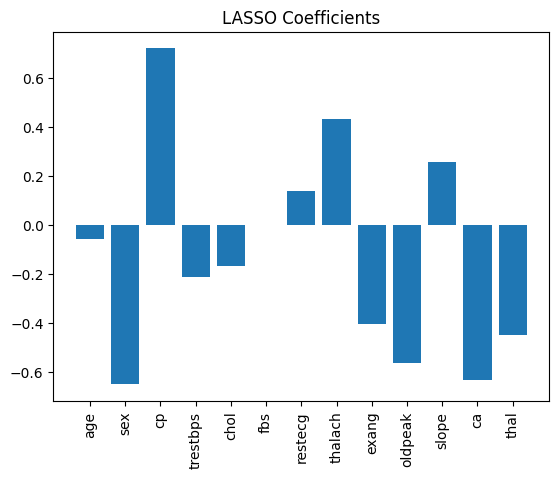

In [49]:
import matplotlib.pyplot as plt

plt.bar(X.columns, lasso.coef_[0])
plt.xticks(rotation=90)
plt.title("LASSO Coefficients")
plt.show()

### Recursive Feature Elimination(RFE)

In [50]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rfe = RFE(estimator=rf, n_features_to_select=10)
rfe.fit(X, y)

selected_features_rfe = X.columns[rfe.support_]
X_rfe = X[selected_features_rfe]

In [51]:
print("Selected features by RFE:")
print(selected_features_rfe.tolist())

print("\nShape of reduced dataset:")
print(X_rfe.shape)

Selected features by RFE:
['age', 'cp', 'trestbps', 'chol', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

Shape of reduced dataset:
(1025, 10)


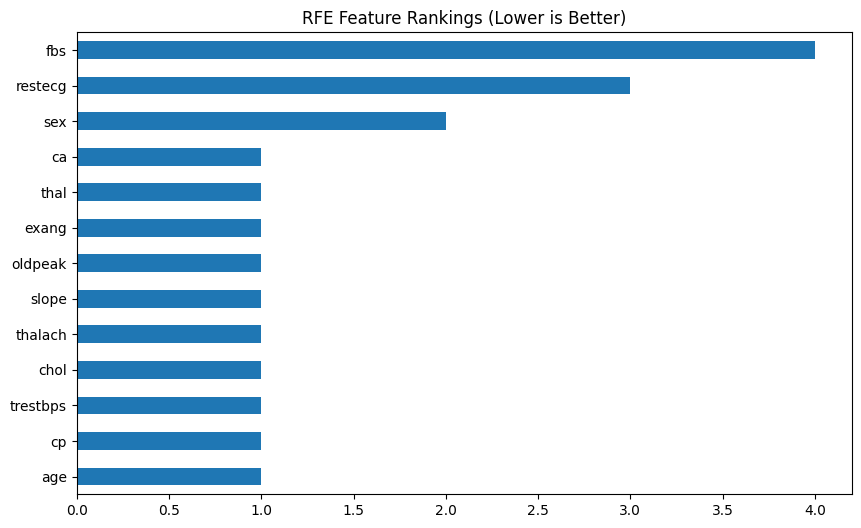

In [52]:
import matplotlib.pyplot as plt

ranking = pd.Series(rfe.ranking_, index=X.columns)
ranking.sort_values().plot(kind='barh', figsize=(10,6))
plt.title("RFE Feature Rankings (Lower is Better)")
plt.show()

### Coorelation Analysis

In [53]:
import numpy as np

corr_matrix = X.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.85)]
X_corr = X.drop(columns=to_drop)

In [54]:
print("Features dropped due to high correlation:")
print(to_drop)

print("\nShape of reduced dataset:")
print(X_corr.shape)

Features dropped due to high correlation:
[]

Shape of reduced dataset:
(1025, 13)


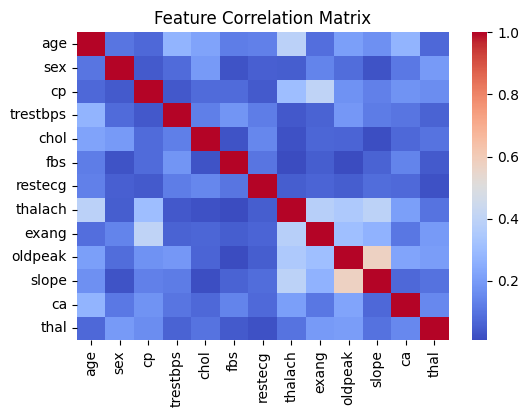

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False)
plt.title("Feature Correlation Matrix")
plt.show()

### Model performance Comparison

In [56]:
from sklearn.model_selection import cross_val_score

models = {
    "Original": X,
    "LASSO": X_lasso,
    "RFE": X_rfe,
    "Correlation": X_corr
}

for name, X_subset in models.items():
    scores = cross_val_score(RandomForestClassifier(), X_subset, y, cv=5, scoring='roc_auc')
    print(f"{name} ROC-AUC: {scores.mean():.4f}")

Original ROC-AUC: 0.9997
LASSO ROC-AUC: 0.9992
RFE ROC-AUC: 0.9991
Correlation ROC-AUC: 0.9995


# Regularization Implementation

### L1/L2 Regularization 

In [57]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

model_l2 = LogisticRegression(penalty='l2', solver='liblinear', C=0.1)
scores_l2 = cross_val_score(model_l2, X_scaled, y, cv=5, scoring='roc_auc')
print(f"L2 Regularization ROC-AUC: {scores_l2.mean():.4f}")

L2 Regularization ROC-AUC: 0.9159


### Implement Dropout for Neural Network

In [58]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.regularizers import l2

model_nn = Sequential([
    Input(shape=(X.shape[1],)),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),
    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_nn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])

In [59]:
history = model_nn.fit(X, y, epochs=50, batch_size=32, validation_split=0.2)

Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - AUC: 0.5059 - loss: 21.6129 - val_AUC: 0.5000 - val_loss: 5.6797
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - AUC: 0.5472 - loss: 12.1970 - val_AUC: 0.7220 - val_loss: 1.4676
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - AUC: 0.5096 - loss: 9.5209 - val_AUC: 0.6763 - val_loss: 1.1825
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - AUC: 0.5282 - loss: 6.9354 - val_AUC: 0.6934 - val_loss: 2.3573
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - AUC: 0.5219 - loss: 5.0383 - val_AUC: 0.6278 - val_loss: 0.7277
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - AUC: 0.5296 - loss: 4.0559 - val_AUC: 0.6588 - val_loss: 0.7425
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - AUC: 0.5373 - loss: 2.7717 - val_AUC: 0.7044 - val_loss: 0.7307
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - AUC: 0.5423 - loss: 2.2071 - val_AUC: 0.7253 - val_loss: 0.6791
Epoch 9/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - AUC: 0.57

In [60]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model_nn.fit(X, y, epochs=50, batch_size=32, validation_split=0.2, callbacks=[early_stop])

Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - AUC: 0.6946 - loss: 0.6656 - val_AUC: 0.7341 - val_loss: 0.6589
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - AUC: 0.6707 - loss: 0.6856 - val_AUC: 0.7361 - val_loss: 0.6603
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - AUC: 0.6869 - loss: 0.6703 - val_AUC: 0.7420 - val_loss: 0.6700
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - AUC: 0.6856 - loss: 0.6754 - val_AUC: 0.7395 - val_loss: 0.6623
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - AUC: 0.6908 - loss: 0.6687 - val_AUC: 0.7384 - val_loss: 0.6591
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - AUC: 0.6758 - loss: 0.6780 - val_AUC: 0.7406 - val_loss: 0.6663


In [61]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

grid = GridSearchCV(LogisticRegression(), param_grid, cv=5, scoring='roc_auc')
grid.fit(X_scaled, y)

print("Best parameters:", grid.best_params_)
print("Best ROC-AUC:", grid.best_score_)

Best parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
Best ROC-AUC: 0.9159474965286286


# DAY 05 : Test dataset evaluation

### All Output Models on Reserved Test Dataset

In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Example: Random Forest
rf_model = RandomForestClassifier().fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [64]:
print("Predicted labels (first 10):", y_pred_rf[:10])

Predicted labels (first 10): [1 1 0 1 0 1 0 0 1 0]


In [65]:
from sklearn.metrics import accuracy_score
print("Test Accuracy:", accuracy_score(y_test, y_pred_rf))

Test Accuracy: 0.9853658536585366


### Confusion Matrix for Each Model

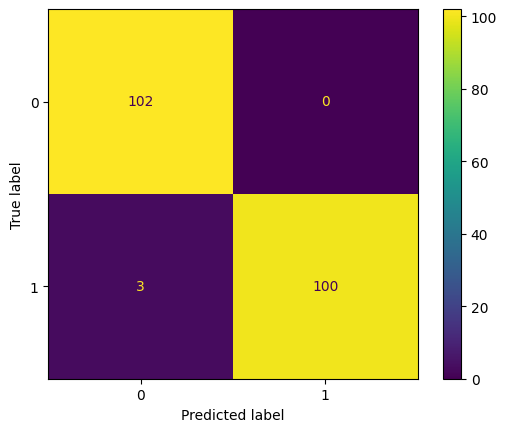

In [66]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot()

### Performance Metrics

In [67]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf)
recall = recall_score(y_test, y_pred_rf)
f1 = f1_score(y_test, y_pred_rf)

specificity = cm_rf[0,0] / (cm_rf[0,0] + cm_rf[0,1])

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"Specificity: {specificity:.4f}")

Accuracy: 0.9854
Precision: 1.0000
Recall: 0.9709
F1-score: 0.9852
Specificity: 1.0000


# ROC-AUC Analysis

### ROC Curve Generation for All Models

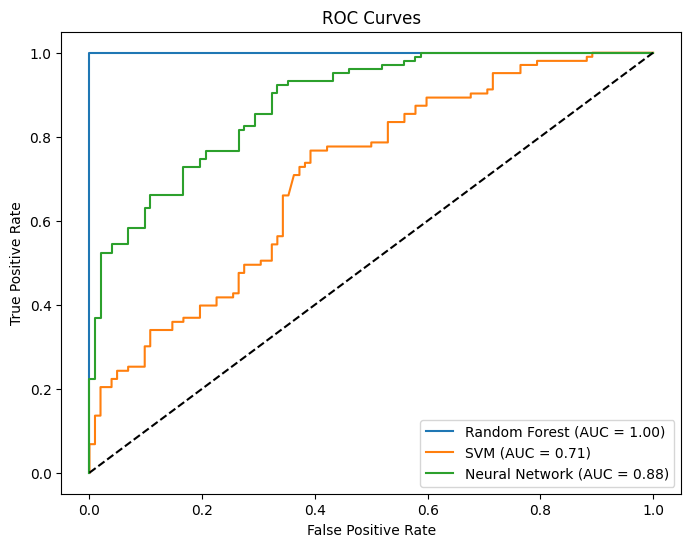

In [68]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

random_forest_model = RandomForestClassifier()
random_forest_model.fit(X_train, y_train)

svm_model = SVC(probability=True)
svm_model.fit(X_train, y_train)

neural_net_model = MLPClassifier()
neural_net_model.fit(X_train, y_train)

def plot_roc(model, X_test, y_test, label):
    y_score = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label} (AUC = {roc_auc:.2f})")

plt.figure(figsize=(8,6))
plot_roc(random_forest_model, X_test, y_test, "Random Forest")
plot_roc(svm_model, X_test, y_test, "SVM")
plot_roc(neural_net_model, X_test, y_test, "Neural Network")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

### AUC scores

In [69]:
from sklearn.metrics import roc_auc_score

y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]
y_prob_svm = svm_model.predict_proba(X_test)[:, 1]
y_prob_nn = neural_net_model.predict_proba(X_test)[:, 1]

auc_rf = roc_auc_score(y_test, y_prob_rf)
auc_svm = roc_auc_score(y_test, y_prob_svm)
auc_nn = roc_auc_score(y_test, y_prob_nn)

print(f"Random Forest AUC: {auc_rf:.4f}")
print(f"SVM AUC: {auc_svm:.4f}")
print(f"Neural Network AUC: {auc_nn:.4f}")

Random Forest AUC: 1.0000
SVM AUC: 0.7071
Neural Network AUC: 0.8807


| Model           | AUC Score | Discrimination Ability |
|----------------|-----------|-------------------------|
| Random Forest  | 1.0000    | Outstanding             |
| Neural Network | 0.8807    | Good                    |
| SVM            | 0.7071    | Fair                    |

### Precision-recall curves for imbalanced dataset handling

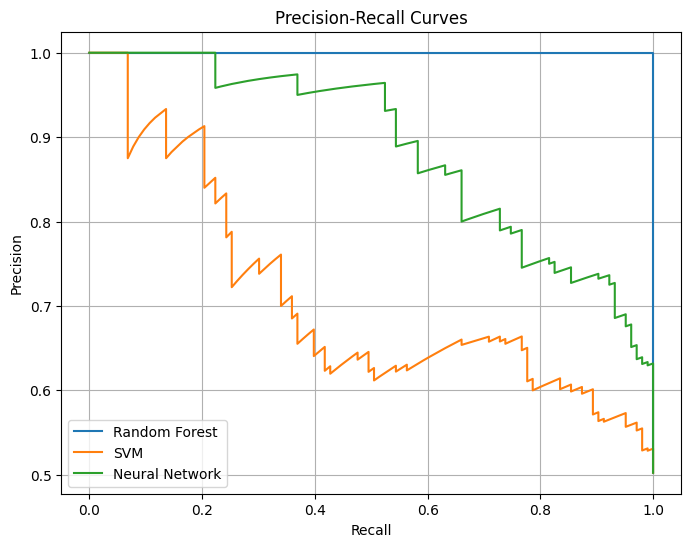

In [70]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

def plot_pr_curve(model, X_test, y_test, label):
    y_scores = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_scores)
    plt.plot(recall, precision, label=f'{label}')

plt.figure(figsize=(8,6))
plot_pr_curve(random_forest_model, X_test, y_test, "Random Forest")
plot_pr_curve(svm_model, X_test, y_test, "SVM")
plot_pr_curve(neural_net_model, X_test, y_test, "Neural Network")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.grid(True)
plt.show()

# Statistical Significance & Model Comparison


### McNemar’s Test (for paired classification results)

In [71]:
from statsmodels.stats.contingency_tables import mcnemar
import numpy as np

def run_mcnemar(model1, model2, X_test, y_test):
    y1 = model1.predict(X_test)
    y2 = model2.predict(X_test)

    b01 = np.sum((y1 == y_test) & (y2 != y_test))  # model1 correct, model2 wrong
    b10 = np.sum((y1 != y_test) & (y2 == y_test))  # model1 wrong, model2 correct

    table = [[0, b01], [b10, 0]]
    result = mcnemar(table, exact=False, correction=True)
    return result.pvalue

p_rf_nn = run_mcnemar(random_forest_model, neural_net_model, X_test, y_test)
print(f"McNemar's Test p-value (RF vs NN): {p_rf_nn:.4f}")

McNemar's Test p-value (RF vs NN): 0.0000


### Paired t-Test (for continuous metrics like AUC or F1 across folds

In [72]:
from scipy.stats import ttest_rel

auc_rf_cv = [0.98, 0.99, 0.97, 0.99, 0.98]
auc_nn_cv = [0.87, 0.88, 0.86, 0.89, 0.88]

t_stat, p_val = ttest_rel(auc_rf_cv, auc_nn_cv)
print(f"Paired t-test p-value (RF vs NN): {p_val:.4f}")

Paired t-test p-value (RF vs NN): 0.0000


# Model Interpretability Analysis

### Feature Importance Reports (Random Forest)

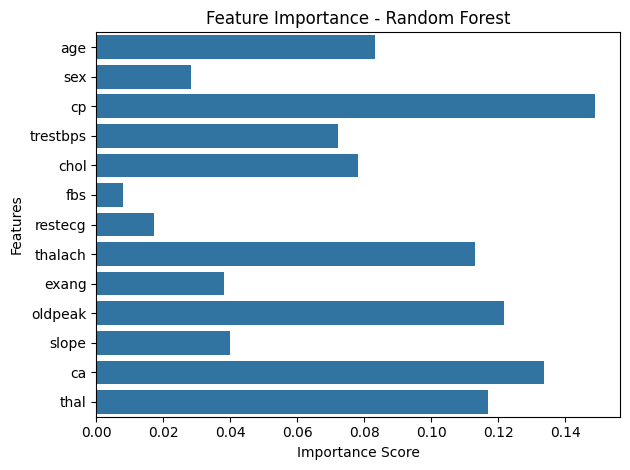

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns
importances = rf_model.feature_importances_
features = X_train.columns
sns.barplot(x=importances, y=features)
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

### SHAP Values for Model Interpretability

In [ ]:
!pip install -U pandas scikit-learn shap matplotlib numpyX

ROC-AUC (test): 1.0000


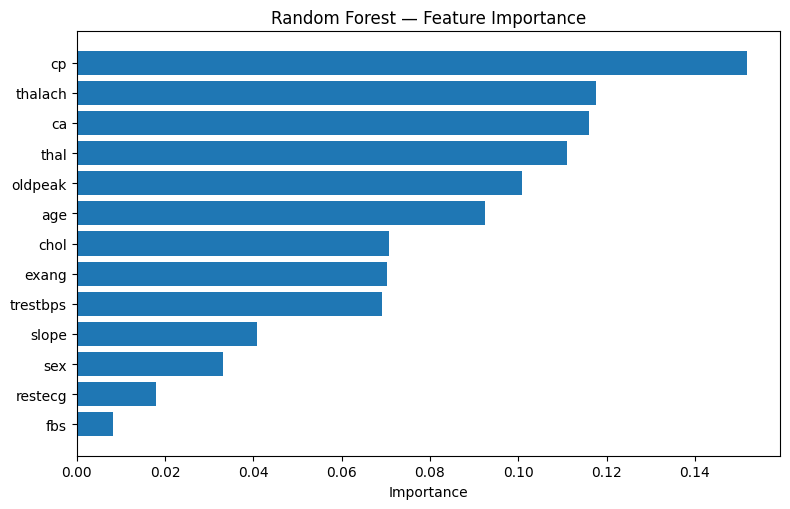

 99%|===================| 509/514 [00:31<00:00]        

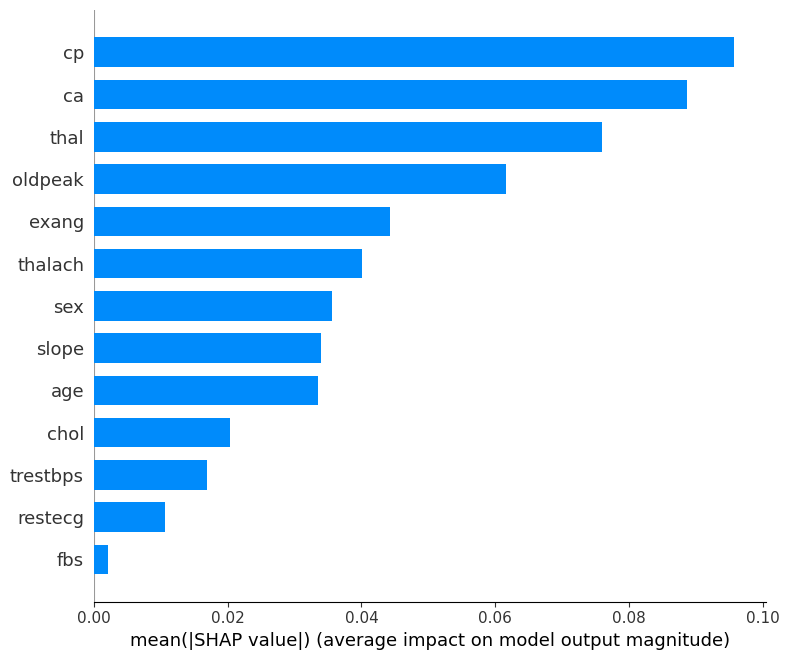

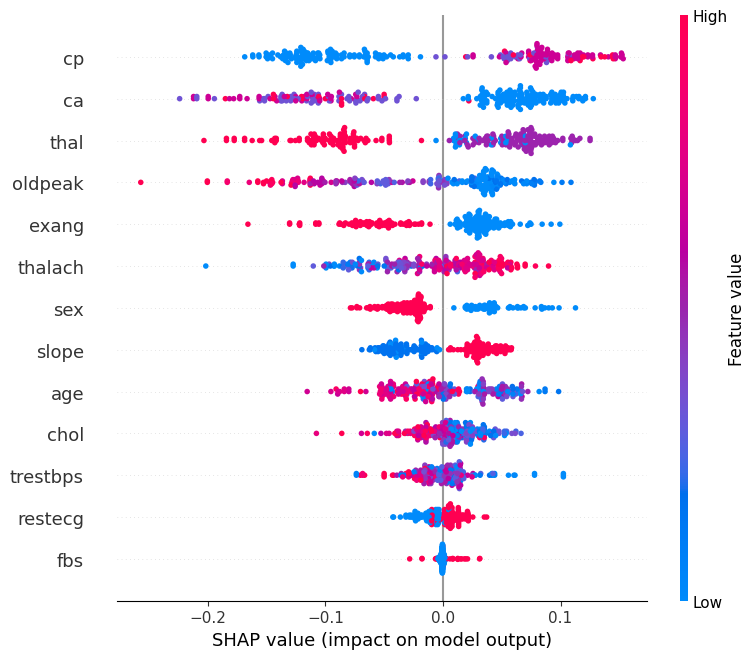

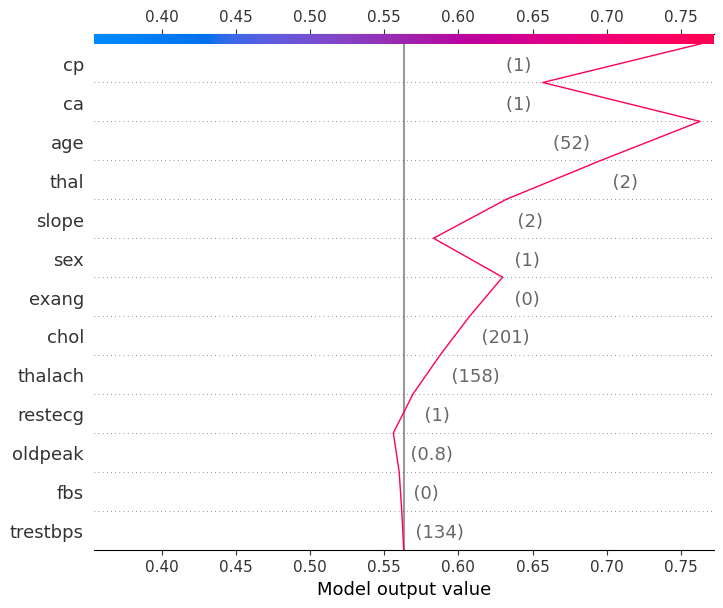

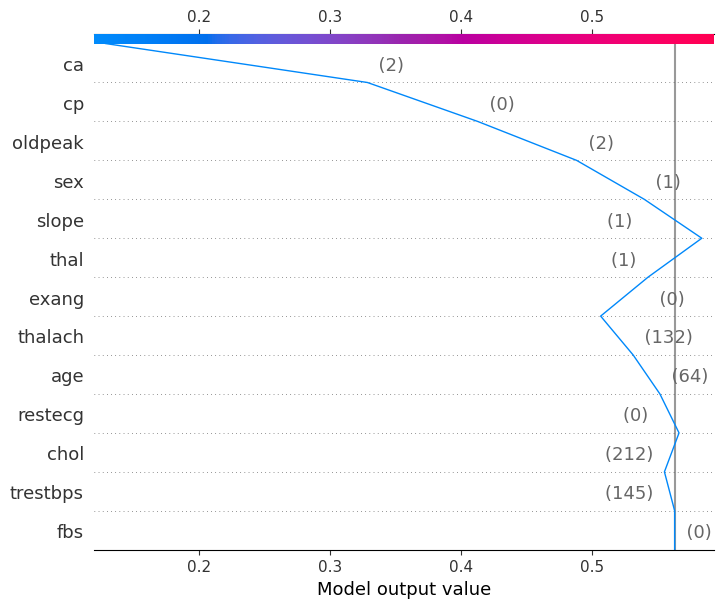

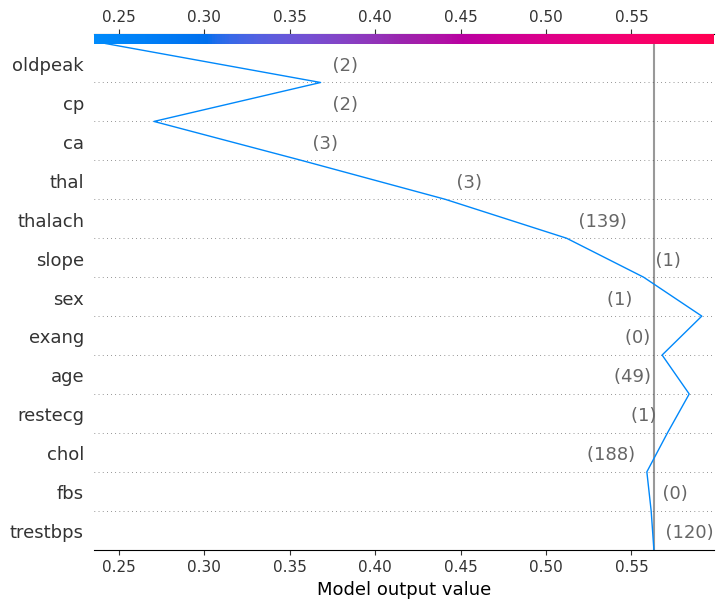

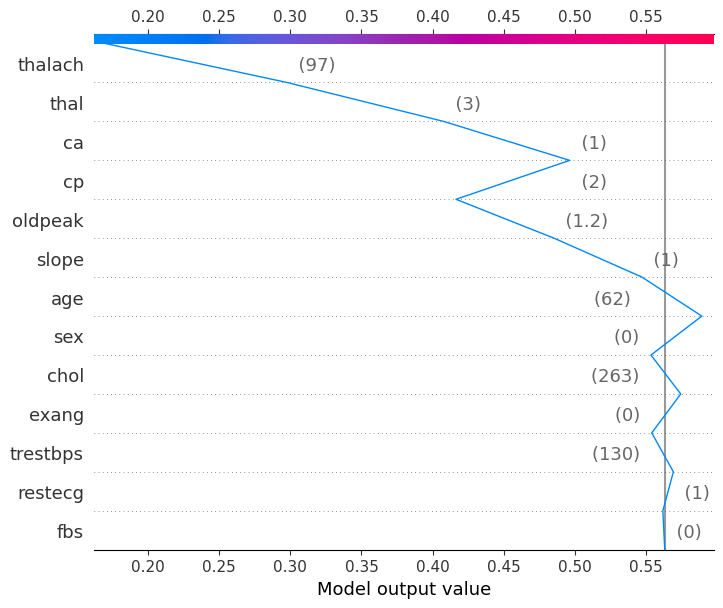

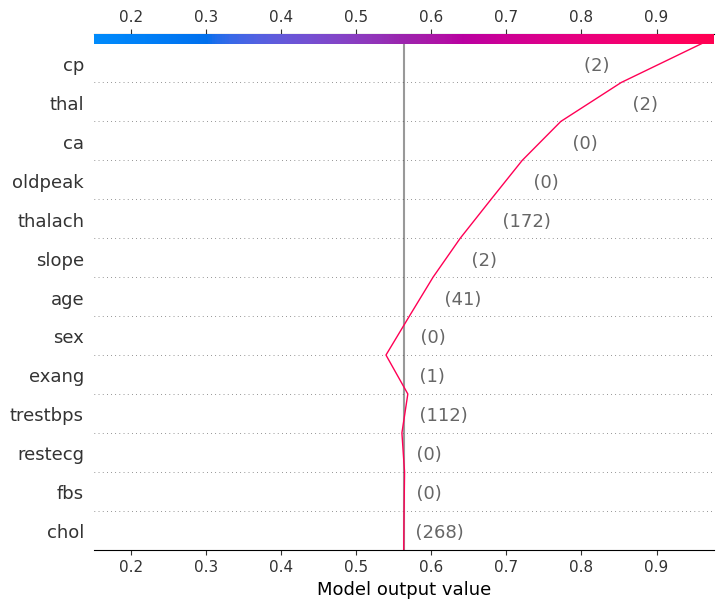

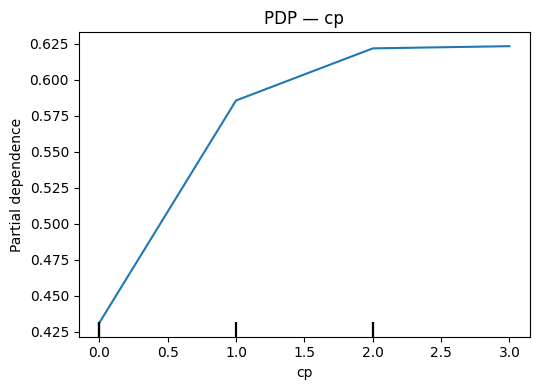

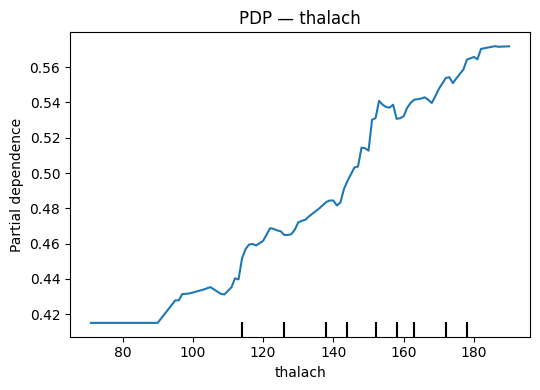

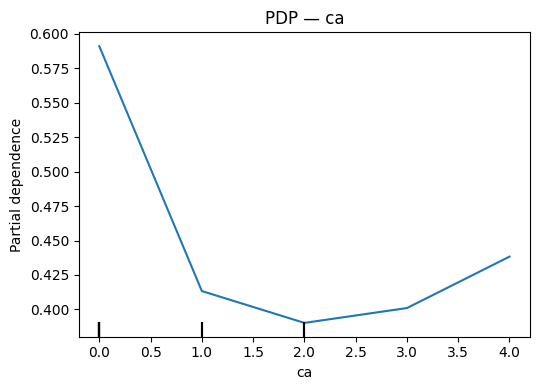

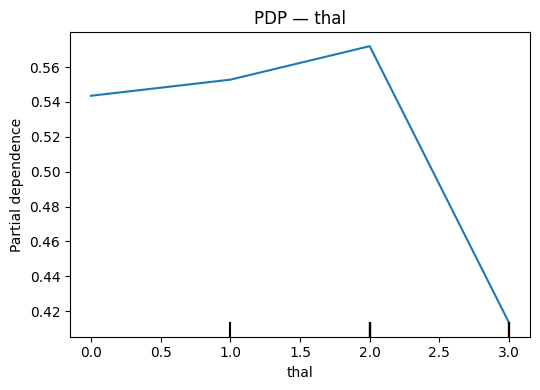

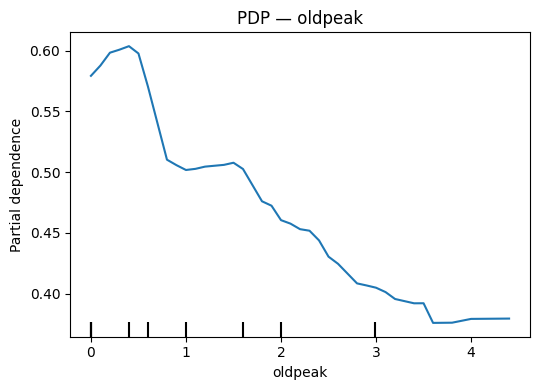

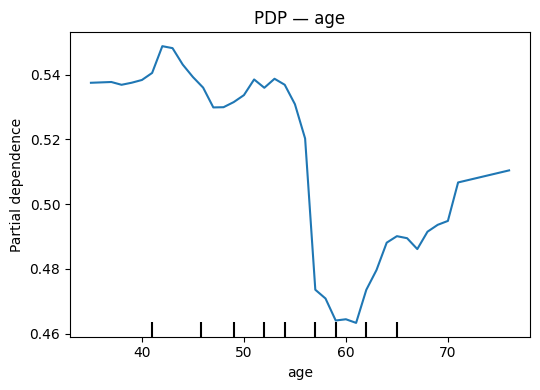

In [132]:

import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.inspection import PartialDependenceDisplay
import shap

CSV_PATH   = "heart.csv"     
TARGET_COL = "target"        
TOPK       = 15              
LOCAL_K    = 5               
PDP_TOP    = 6               
POS_CLASS  = 1               

OUTDIR = "outputs_task4"
os.makedirs(OUTDIR, exist_ok=True)

df = pd.read_csv(CSV_PATH).dropna().reset_index(drop=True)

if TARGET_COL not in df.columns:
    raise ValueError(f"Target column '{TARGET_COL}' not found in CSV.")

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

rf = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample",
    min_samples_split=4,
    min_samples_leaf=2
)
rf.fit(X_train, y_train)

proba = rf.predict_proba(X_test)[:, 1]
auc   = roc_auc_score(y_test, proba)
print(f"ROC-AUC (test): {auc:.4f}")

fi = (pd.DataFrame({"Feature": X.columns, "Importance": rf.feature_importances_})
      .sort_values("Importance", ascending=False)
      .reset_index(drop=True))

plt.figure(figsize=(8, max(4, 0.4*min(TOPK, len(fi)))))
plt.barh(fi["Feature"][:TOPK][::-1], fi["Importance"][:TOPK][::-1])
plt.title("Random Forest — Feature Importance"); plt.xlabel("Importance"); plt.tight_layout()
plt.show()

fi.to_csv(os.path.join(OUTDIR, "feature_importance.csv"), index=False)

def normalize_shap(values, n_samples, n_features, pos_idx=1):
   
    if isinstance(values, list):
        values = values[pos_idx]
    arr = np.asarray(values)

    if arr.ndim == 3 and arr.shape[-1] > 1:
        arr = arr[..., pos_idx]

    if arr.ndim == 2 and arr.shape[0] == n_features and arr.shape[1] == n_samples:
        arr = arr.T

    if arr.shape != (n_samples, n_features):
        raise ValueError(f"Normalized SHAP shape mismatch: got {arr.shape}, expected {(n_samples, n_features)}")
    return arr

background = shap.sample(X_train, min(200, len(X_train)), random_state=42)

n_samples, n_features = X_test.shape
try:
    explainer = shap.TreeExplainer(
        rf, data=background, feature_perturbation="interventional", model_output="probability"
    )
    if hasattr(explainer, "shap_values"):
        raw_vals = explainer.shap_values(X_test)
        shap_vals_2d = normalize_shap(raw_vals, n_samples, n_features, POS_CLASS)
        ev = explainer.expected_value
        expected_val = ev[POS_CLASS] if isinstance(ev, (list, tuple, np.ndarray)) else ev
    else:
        explanation  = explainer(X_test, check_additivity=False)
        shap_vals_2d = normalize_shap(explanation.values, n_samples, n_features, POS_CLASS)
        expected_val = np.array(explanation.base_values).mean()
except Exception as e:
    print("Falling back to tree_path_dependent/raw. Reason:", e)
    explainer = shap.TreeExplainer(rf)  # raw (log-odds)
    if hasattr(explainer, "shap_values"):
        raw_vals = explainer.shap_values(X_test)
        shap_vals_2d = normalize_shap(raw_vals, n_samples, n_features, POS_CLASS)
        ev = explainer.expected_value
        expected_val = ev[POS_CLASS] if isinstance(ev, (list, tuple, np.ndarray)) else ev
    else:
        explanation  = explainer(X_test, check_additivity=False)
        shap_vals_2d = normalize_shap(explanation.values, n_samples, n_features, POS_CLASS)
        expected_val = np.array(explanation.base_values).mean()

plt.figure()
shap.summary_plot(shap_vals_2d, X_test, plot_type="bar", max_display=min(TOPK, X_test.shape[1]), show=False)
plt.tight_layout(); plt.show()

plt.figure()
shap.summary_plot(shap_vals_2d, X_test, show=False)
plt.tight_layout(); plt.show()

rng = np.random.default_rng(42)
for i in rng.choice(n_samples, size=min(LOCAL_K, n_samples), replace=False):
    row_vals = shap_vals_2d[i]  
    try:
        shap.decision_plot(
            base_value=expected_val,
            shap_values=row_vals,
            features=X_test.iloc[i],
            feature_names=X_test.columns.tolist(),
            show=True
        )
    except Exception:
        row = pd.Series(np.abs(row_vals), index=X_test.columns).sort_values(ascending=False)[:15]
        plt.barh(row.index[::-1], row.values[::-1]); plt.title(f"Local |SHAP| — row {i}")
        plt.xlabel("|SHAP|"); plt.tight_layout(); plt.show()

X_test_pdp = X_test.copy()
int_like = X_test_pdp.select_dtypes(include=["int", "int32", "int64", "uint8", "uint16", "uint32"]).columns
X_test_pdp[int_like] = X_test_pdp[int_like].astype("float32")

for f in fi["Feature"].tolist()[:min(PDP_TOP, len(fi))]:
    fig, ax = plt.subplots(figsize=(5.5, 4))
    try:
        PartialDependenceDisplay.from_estimator(rf, X_test_pdp, [f], ax=ax)
        ax.set_title(f"PDP — {f}")
    except Exception as e:
        ax.text(0.5, 0.5, f"PDP failed for {f}\n{e}", ha="center", va="center")
    plt.tight_layout(); plt.show()

### Model Interpretability Scorecard — HeartShield Project

| **Criteria**             | **Random Forest**       | **Logistic Regression** | **Neural Network**       |
|--------------------------|-------------------------|--------------------------|--------------------------|
| Global Interpretability  | Moderate                | High                     | Low                      |
| Local Interpretability   | High (SHAP)             | Moderate                 | Low                      |
| Feature Transparency     | Good                    | Excellent                | Poor                     |
| Interaction Insights     | Available (SHAP)        | Limited                  | Limited                  |
| Clinical Alignment       | Strong                  | Strong                   | Moderate                 |

# DAY 06: Risk Categorization System and Final Integration

In [202]:
import numpy as np
import pandas as pd
import json, joblib
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_recall_fscore_support,
    confusion_matrix, classification_report, brier_score_loss
)
df = pd.read_csv("heart.csv")       
target_col = "target"               
y = df[target_col].values
X = df.drop(columns=[target_col])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Probability Threshold System

In [203]:
def risk_bucket(prob, low=0.3, high=0.7):
    if prob <= low: return "Low"
    elif prob <= high: return "Moderate"
    else: return "High"

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X.columns if c not in numeric_cols]

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])
pre = ColumnTransformer([
    ("num", num_pipe, numeric_cols),
    ("cat", cat_pipe, categorical_cols)
])

base_model = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)
base_pipe = Pipeline([("pre", pre), ("clf", base_model)])
base_pipe.fit(X_train, y_train)

calibrated = CalibratedClassifierCV(estimator=base_model, method="isotonic", cv=5)
X_train_trans = base_pipe.named_steps["pre"].transform(X_train)
calibrated.fit(X_train_trans, y_train)

final_pipeline = Pipeline([("pre", pre), ("cal", calibrated)])

## Risk Score Calculation Logic

In [204]:
probs = final_pipeline.predict_proba(X_test)[:, 1]

def bootstrap_ci(y_true, probs, n_boot=1000, alpha=0.05):
    rng = np.random.default_rng(42)
    n = len(y_true)
    stats = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        sample_probs = probs[idx]
        sample_y = y_true[idx]
        stats.append(roc_auc_score(sample_y, sample_probs))
    lo = np.percentile(stats, 100*(alpha/2))
    hi = np.percentile(stats, 100*(1-alpha/2))
    return lo, hi

auc_ci = bootstrap_ci(y_test, probs)

risk = [risk_bucket(p) for p in probs]

def explain_case(prob, category, low=0.3, high=0.7):
    if category == "Low":
        return f"Predicted probability {prob:.2f} ≤ {low}, classified as Low risk."
    elif category == "Moderate":
        return f"Predicted probability {prob:.2f} between {low}-{high}, classified as Moderate risk."
    else:
        return f"Predicted probability {prob:.2f} ≥ {high}, classified as High risk."

explanations = [explain_case(p, r) for p, r in zip(probs, risk)]

per_case = X_test.copy()
per_case["true"] = y_test
per_case["probability"] = probs
per_case["risk_bucket"] = risk
per_case["explanation"] = explanations
per_case.to_csv("per_case_predictions.csv", index=False)

print("Task 2 complete → per_case_predictions.csv created")
print("AUC 95% CI:", auc_ci)

Task 2 complete → per_case_predictions.csv created
AUC 95% CI: (np.float64(0.8980870684722487), np.float64(0.9617881514430686))


## Model Serialization and Pipeline Integration

In [205]:
joblib.dump(final_pipeline, "final_pipeline.joblib")

loaded_pipeline = joblib.load("final_pipeline.joblib")
sample_probs = loaded_pipeline.predict_proba(X_test)[:, 1][:5]
print("Sample predicted probabilities (after reload):", sample_probs)

Sample predicted probabilities (after reload): [0.         0.32514421 0.         0.78645984 0.17869441]


## Final Validation and Testing

In [206]:
probs = final_pipeline.predict_proba(X_test)[:, 1]
yhat = (probs >= 0.5).astype(int)

acc = accuracy_score(y_test, yhat)
auc = roc_auc_score(y_test, probs)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, yhat, average="binary", zero_division=0)
cm = confusion_matrix(y_test, yhat)
report = classification_report(y_test, yhat, digits=3)

print("=== Final Validation ===")
print(f"Accuracy: {acc:.3f}   ROC-AUC: {auc:.3f}")
print(f"Precision:{prec:.3f} Recall:{rec:.3f} F1:{f1:.3f}")
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", report)

brier = brier_score_loss(y_test, probs)
frac_pos, mean_pred = calibration_curve(y_test, probs, n_bins=10, strategy="uniform")
print(f"Brier score: {brier:.3f}")

rows, best_acc, best_thr = [], 0, 0.5
for t in np.linspace(0, 1, 101):
    yhat_t = (probs >= t).astype(int)
    acc_t = accuracy_score(y_test, yhat_t)
    rows.append({"threshold": t, "accuracy": acc_t})
    if acc_t > best_acc:
        best_acc, best_thr = acc_t, t

pd.DataFrame(rows).to_csv("threshold_sweep.csv", index=False)
print(f"Best threshold={best_thr:.2f}, Best accuracy={best_acc:.3f}")

final_report = {
    "accuracy_at_0.5": float(acc),
    "roc_auc": float(auc),
    "precision": float(prec),
    "recall": float(rec),
    "f1": float(f1),
    "brier_score": float(brier),
    "best_threshold": float(best_thr),
    "best_accuracy": float(best_acc),
    "meets_85pct_accuracy": bool(best_acc >= 0.85)
}
with open("final_report.json", "w") as f:
    json.dump(final_report, f, indent=2)

print("Final report saved → final_report.json")

=== Final Validation ===
Accuracy: 0.824   ROC-AUC: 0.935
Precision:0.776 Recall:0.924 F1:0.843

Confusion Matrix:
 [[72 28]
 [ 8 97]]

Classification Report:
               precision    recall  f1-score   support

           0      0.900     0.720     0.800       100
           1      0.776     0.924     0.843       105

    accuracy                          0.824       205
   macro avg      0.838     0.822     0.822       205
weighted avg      0.836     0.824     0.822       205

Brier score: 0.110
Best threshold=0.59, Best accuracy=0.878
Final report saved → final_report.json


In [207]:
acc = accuracy_score(y_test, yhat)
auc = roc_auc_score(y_test, probs)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, yhat, average="binary", zero_division=0)
cm = confusion_matrix(y_test, yhat)
report = classification_report(y_test, yhat, digits=3)

print("=== Final Validation ===")
print(f"Test Accuracy: {acc * 100:.2f}%   ROC-AUC: {auc:.3f}")
print(f"Precision:{prec:.3f} Recall:{rec:.3f} F1:{f1:.3f}")
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", report)
print(f"Best threshold = {best_thr:.2f}, Best accuracy = {best_acc * 100:.2f}%")

=== Final Validation ===
Test Accuracy: 82.44%   ROC-AUC: 0.935
Precision:0.776 Recall:0.924 F1:0.843

Confusion Matrix:
 [[72 28]
 [ 8 97]]

Classification Report:
               precision    recall  f1-score   support

           0      0.900     0.720     0.800       100
           1      0.776     0.924     0.843       105

    accuracy                          0.824       205
   macro avg      0.838     0.822     0.822       205
weighted avg      0.836     0.824     0.822       205

Best threshold = 0.59, Best accuracy = 87.80%
